# Kilonovae

This page is the reference for {class}`skysurvey.Kilonova`, the built-in model for kilonovae: the optical and
infrared transients powered by the radioactive decay of heavy elements produced in neutron-star mergers.
You will see which template it uses, its default rate, and how its parameters (including the viewing angle)
are drawn.

:::{tip}
If you are new to `skysurvey`, start with the [target quickstart](../quickstart/quickstart_target.ipynb).
This page focuses on the *default settings* of the kilonova model.
:::

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import skysurvey
from skysurvey.target.rates import get_ntargets

## Overview

{class}`skysurvey.Kilonova` is a ready-to-use {class}`skysurvey.Transient`:

| Property | Default | Reference |
|---|---|---|
| Template | POSSIS binary neutron-star model, viewing-angle dependent | Bulla (2019) |
| Volumetric rate | $10^{3}\ \mathrm{Gpc^{-3}\,yr^{-1}}$ (for $H_0=70$) | of the order of the BNS merger rate (Abbott et al. 2023) |
| Absolute magnitude | $\mathcal{N}(-18, 1)$ | |
| Viewing angle $\theta$ | uniform in $[0, 90]$ deg | |
| Redshift | follows the rate, $z \le 0.2$ | |
| Sky position | uniform over the full sky | |

In [2]:
kilonova = skysurvey.Kilonova()
print(kilonova.kind, "|", kilonova.rate, "kilonovae / Gpc3 / yr (for H0 =", kilonova._rateh0, ")")

kilonova | 1000.0 kilonovae / Gpc3 / yr (for H0 = 70.0 )


## Template

The template is a spectral time series computed with the radiative-transfer code POSSIS (Bulla 2019) for a
binary neutron-star (BNS) merger. The default model file, `nsns_nph1.0e+06_mejdyn0.020_mejwind0.130_phi30.txt`
(shipped with `skysurvey`, from the [kilonova_models](https://github.com/mbulla/kilonova_models) repository),
corresponds to a dynamical ejecta mass of $0.02\,M_\odot$, a post-merger wind ejecta mass of $0.13\,M_\odot$ and
a half-opening angle $\phi = 30^\circ$ of the lanthanide-rich component (simulated with $10^6$ photon packets).

Because the ejecta are not spherical, the spectrum depends on the viewing angle. The model is therefore loaded as
an {class}`~skysurvey.source.angular.AngularTimeSeriesSource`, a `sncosmo` source with an extra parameter `theta`:

In [3]:
source = kilonova.template.source
print(source)
print(f"phase: {source.minphase()} to {source.maxphase()} days after merger")
print(f"wavelength: {source.minwave():.0f} to {source.maxwave():.0f} Angstrom")

class      : AngularTimeSeriesSource
name       : 'kilonova'
version    : None
phases     : [0, .., 20] days
wavelengths: [100, .., 99900] Angstroms
parameters:
  amplitude = np.float64(1.0)
  theta     = np.float64(0.0)
phase: 0.0 to 20.0 days after merger
wavelength: 100 to 99900 Angstrom


The full template parameters are `z`, `t0` (the time of the merger, i.e. phase zero), `amplitude`
(set by `skysurvey` from the drawn absolute magnitude) and `theta`, the viewing angle in degrees
($0^\circ$: polar view, $90^\circ$: edge-on, in the equatorial plane):

In [4]:
kilonova.template.parameters

['z', 't0', 'amplitude', 'theta']

Kilonovae evolve fast: they peak about a day after the merger and fade by several magnitudes within a week.
The viewing angle matters: seen from the equator, where the lanthanide-rich (high-opacity) dynamical ejecta lie,
the kilonova appears fainter. Here is the template at rest ($z=0$) for three viewing angles,
using {meth}`~skysurvey.Template.get` to get a copy of the `sncosmo.Model` with the given parameters:

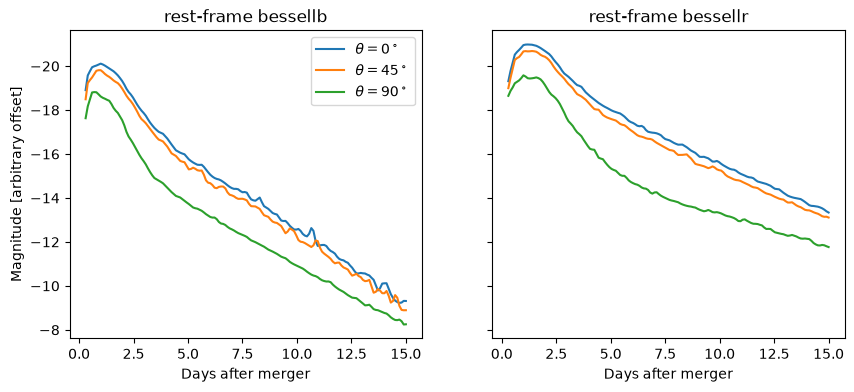

In [5]:
phase = np.linspace(0.3, 15, 150)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, band in zip(axes, ["bessellb", "bessellr"]):
    for theta in [0, 45, 90]:
        model = kilonova.template.get(t0=0, theta=theta)  # z=0 and amplitude=1 by default
        ax.plot(phase, model.bandmag(band, "ab", phase), label=rf"$\theta = {theta}^\circ$")
    ax.set(xlabel="Days after merger", title=f"rest-frame {band}")
axes[0].set_ylabel("Magnitude [arbitrary offset]")
axes[0].invert_yaxis()
axes[0].legend();

:::{note}
When light curves are simulated, `skysurvey` rescales the `amplitude` of each target so that its peak
(rest-frame Bessell B, AB) magnitude equals the drawn `magabs`. The brightness difference between viewing angles
shown above is therefore *not* kept: `theta` only changes the color and the shape of the light curve.
:::

To use another POSSIS model, load it with {func}`skysurvey.get_kilonova_model` and pass it as `template`:

```python
from skysurvey.target.kilonova import get_kilonova_model
model = get_kilonova_model("path/to/another_possis_file.txt")
kilonova = skysurvey.Kilonova.from_draw(size=1_000, template=model)
```

## Rate

The default volumetric rate is $10^{3}\ \mathrm{Gpc^{-3}\,yr^{-1}}$ (assuming $H_0=70$), constant with redshift.
It is within the range of BNS merger rates inferred from gravitational-wave observations,
$10$–$1700\ \mathrm{Gpc^{-3}\,yr^{-1}}$ (Abbott et al. 2023), which is very uncertain.
As for any transient, `skysurvey` rescales it by $(H_0/70)^3$ to the target cosmology and divides it by $(1+z)$
for time dilation. Here are the expected number of events per year over the full sky:

In [6]:
for zmax in [0.01, 0.05, 0.1, 0.2]:
    n = get_ntargets(zmax, rate=kilonova.rate, rate_H0=kilonova._rateh0,
                     cosmology=kilonova.cosmology, astype=float)
    print(f"z < {zmax}: {n:>8,.1f} kilonovae per year")

z < 0.01:      0.3 kilonovae per year
z < 0.05:     38.2 kilonovae per year
z < 0.1:    284.9 kilonovae per year
z < 0.2:  1,979.4 kilonovae per year


To use another rate, see [change the rate](../howto/change_rate.ipynb).

## Model

The model describes how each parameter is drawn
(see [modeldag](https://github.com/MickaelRigault/modeldag) for the syntax):

In [7]:
kilonova.model

{'t0': {'func': <bound method Generator.uniform of Generator(PCG64) at 0x302EAA0A0>,
        'kwargs': {'low': 56000, 'high': 56200}},
 'redshift': {'kwargs': {'zmax': 0.2}, 'as': 'z'},
 'magabs': {'func': <bound method Generator.normal of Generator(PCG64) at 0x302EAA0A0>,
            'kwargs': {'loc': -18, 'scale': 1}},
 'magobs': {'func': 'magabs_to_magobs',
            'kwargs': {'z': '@z', 'magabs': '@magabs'}},
 'theta': {'func': <bound method Generator.uniform of Generator(PCG64) at 0x302EAA0A0>,
           'kwargs': {'low': 0.0, 'high': 90.0}},
 'radec': {'func': <function random_radec at 0x17f337b00>,
           'kwargs': {},
           'as': ['ra', 'dec']}}

| Entry | Default |
|---|---|
| `t0` | merger time, uniform between MJD 56 000 and 56 200 (set it with `tstart` and `tstop`) |
| `redshift` | follows the rate, $z \le 0.2$ |
| `magabs` | peak absolute magnitude (Bessell B, AB), Gaussian $\mathcal{N}(-18, 1)$ |
| `magobs` | `magabs` + distance modulus $\mu(z)$ |
| `theta` | viewing angle, uniform between 0 and 90 deg |
| `radec` | uniform over the full sky |

Let us draw a sample to look at the distributions:

In [8]:
kilonova = skysurvey.Kilonova.from_draw(size=3_000)
kilonova.data.head()

,t0,z,magabs,theta,ra,dec,magobs,template
0,56024.515625,0.09545,-17.963724,41.751720,198.323441,32.187557,20.315815,kilonova
1,56059.125000,0.12965,-20.153690,0.535263,42.947304,-32.619228,18.839153,kilonova
2,56094.609375,0.17375,-18.944445,65.045876,110.251167,-11.603036,20.743132,kilonova
3,56096.976562,0.16275,-17.522511,65.058266,344.076141,-60.787598,22.008675,kilonova
4,56055.265625,0.17615,-17.690615,24.518696,191.354187,51.145245,22.029858,kilonova


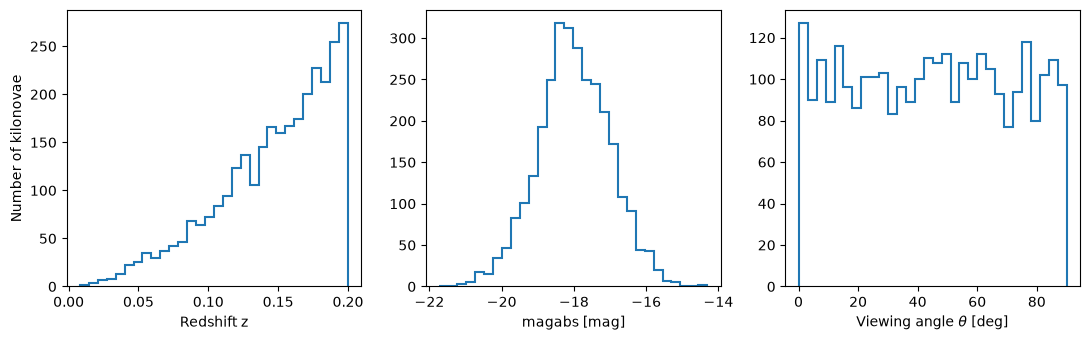

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
for ax, key, label in zip(axes, ["z", "magabs", "theta"],
                          ["Redshift z", "magabs [mag]", r"Viewing angle $\theta$ [deg]"]):
    ax.hist(kilonova.data[key], bins=30, histtype="step", lw=1.5)
    ax.set_xlabel(label)
axes[0].set_ylabel("Number of kilonovae")
fig.tight_layout()

:::{note}
A uniform distribution in $\theta$ is *not* isotropic: for randomly oriented mergers, $\cos\theta$ is uniform,
which favors equatorial views. See the usage example below to change this.
:::

## Usage example

Let us simulate kilonovae within $z<0.05$ (about 220 Mpc) over one year, with isotropic viewing angles.
Any model entry can be replaced with the `model` option; here `theta` is drawn from a function of ours
(it must accept `size`):

In [10]:
def isotropic_theta(size=None, rng=None):
    """Viewing angles (deg) for randomly oriented mergers: cos(theta) is uniform."""
    rng = np.random.default_rng(rng)
    return np.degrees(np.arccos(rng.uniform(0, 1, size=size)))

kilonova = skysurvey.Kilonova.from_draw(tstart="2026-01-01", tstop="2027-01-01", zmax=0.05,
                                        model={"theta": {"func": isotropic_theta}})
print(f"{len(kilonova.data)} kilonovae, median theta = {kilonova.data['theta'].median():.0f} deg")

38 kilonovae, median theta = 65 deg


And here is the true light curve of the closest one, using {meth}`~skysurvey.Kilonova.get_lightcurve`:

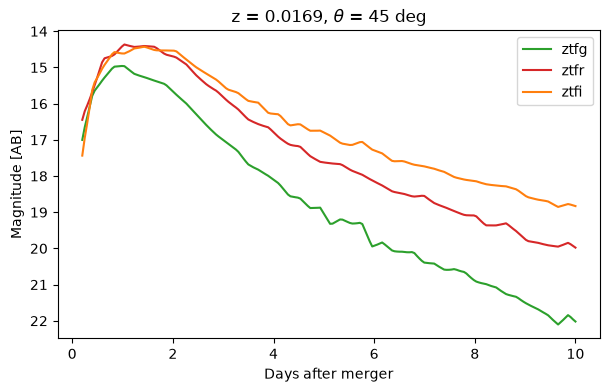

In [11]:
index = kilonova.data["z"].idxmin()
t0, z, theta = kilonova.data.loc[index, ["t0", "z", "theta"]]
times = np.linspace(t0 + 0.2, t0 + 10, 200)
bands = ["ztfg", "ztfr", "ztfi"]
mags = kilonova.get_lightcurve(bands, times, index=index, in_mag=True)  # shape (nbands, ntimes)

fig, ax = plt.subplots(figsize=(7, 4))
for band, mag, color in zip(bands, mags, ["tab:green", "tab:red", "tab:orange"]):
    ax.plot(times - t0, mag, color=color, label=band)
ax.invert_yaxis()
ax.set(xlabel="Days after merger", ylabel="Magnitude [AB]",
       title=rf"z = {z:.4f}, $\theta$ = {theta:.0f} deg")
ax.legend();

## References

- Bulla 2019, *POSSIS: predicting spectra, light curves, and polarization for multidimensional models of supernovae and kilonovae*,
  [MNRAS 489, 5037](https://ui.adsabs.harvard.edu/abs/2019MNRAS.489.5037B)
- POSSIS model grids: [github.com/mbulla/kilonova_models](https://github.com/mbulla/kilonova_models)
- Abbott et al. (LVK) 2023, *Population of merging compact binaries inferred using gravitational waves through GWTC-3*,
  [PRX 13, 011048](https://ui.adsabs.harvard.edu/abs/2023PhRvX..13a1048A)

## Next steps

- [Change the model while drawing](../howto/change_model_while_draw.ipynb) of any target.
- [Change the rate](../howto/change_rate.ipynb), e.g. to explore the uncertain BNS merger rate.
- [Simulate a dataset](../quickstart/quickstart_survey_target_dataset.ipynb): observe your kilonovae with a survey.
- [Build a new transient](../howto/create_new_transient_class.ipynb) from another template.